In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [101]:
ds = load_dataset("dair-ai/emotion")

label_names = ds['train'].features['label'].names
print("Emotion classes:", label_names)

df_train = pd.DataFrame({
    'text': ds['train']['text'],
    'label': [label_names[i] for i in ds['train']['label']]
})

df_test = pd.DataFrame({
    'text': ds['test']['text'],
    'label': [label_names[i] for i in ds['test']['label']]
})

print("Train size:", len(df_train))
print("Test size:", len(df_test))

df_train.head()

Emotion classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train size: 16000
Test size: 2000


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


text     0
label    0
dtype: int64


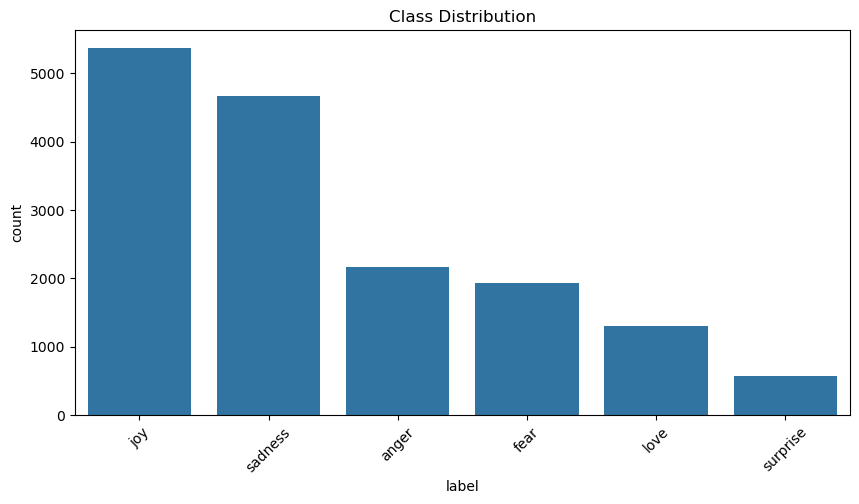

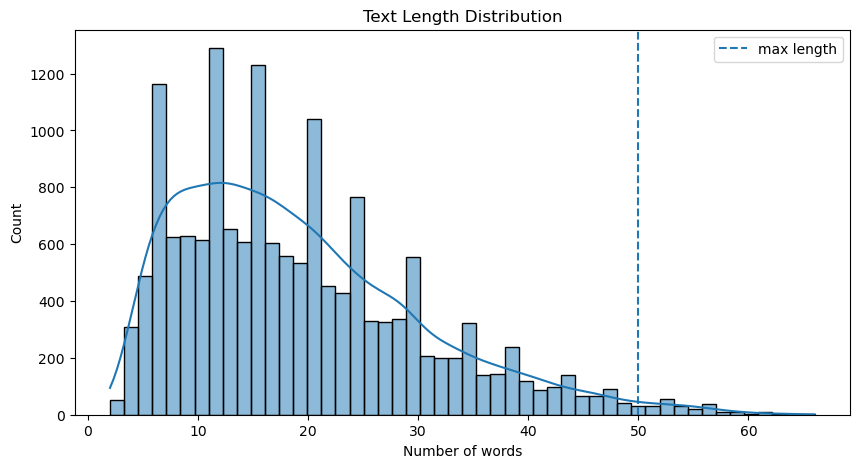

In [102]:
print(df_train.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot( x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

df_train['text_length'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_train['text_length'], bins=50, kde=True)
plt.axvline(50, linestyle='--', label='max length')
plt.xlabel("Number of words")
plt.title("Text Length Distribution")
plt.legend()
plt.show()

In [103]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train['text'].tolist(), ds['train']['label'], test_size=0.1, stratify=ds['train']['label'], random_state=42)

test_texts = df_test['text'].tolist()
test_labels = ds['test']['label']

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 14400, Val: 1600, Test: 2000


In [104]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
vocab_size = tokenizer.vocab_size
pad_token_id = tokenizer.pad_token_id

print(f"Vocabulary size: {vocab_size}, Pad token ID: {pad_token_id}")

MAX_LEN = 50
BATCH_SIZE = 32

def tokenize_texts(texts):
    return tokenizer(texts, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')

train_enc = tokenize_texts(train_texts)
val_enc = tokenize_texts(val_texts)
test_enc = tokenize_texts(test_texts)

print("Train input_ids shape:", train_enc['input_ids'].shape)

Vocabulary size: 30522, Pad token ID: 0
Train input_ids shape: torch.Size([14400, 50])


In [105]:
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

train_dataset = EmotionDataset(train_enc, train_labels)
val_dataset = EmotionDataset(val_enc, val_labels)
test_dataset = EmotionDataset(test_enc, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights_tensor)

Class weights: tensor([0.5716, 0.4973, 2.0443, 1.2352, 1.3769, 4.6602], device='cuda:0')


In [106]:
# LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        x = hidden[-1]
        x = self.dropout(x)
        return self.fc(x)

# GRU Model
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        x = hidden[-1]
        x = self.dropout(x)
        return self.fc(x)

In [116]:
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3):
    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    best_model_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

Epoch 1/20 - Train Loss: 1.7114 - Val Loss: 1.3856
Epoch 2/20 - Train Loss: 0.9271 - Val Loss: 0.6559
Epoch 3/20 - Train Loss: 0.4448 - Val Loss: 0.4930
Epoch 4/20 - Train Loss: 0.2676 - Val Loss: 0.4373
Epoch 5/20 - Train Loss: 0.1763 - Val Loss: 0.4241
Epoch 6/20 - Train Loss: 0.1261 - Val Loss: 0.4428
Epoch 7/20 - Train Loss: 0.0915 - Val Loss: 0.4946
Epoch 8/20 - Train Loss: 0.0624 - Val Loss: 0.5668
Early stopping at epoch 8


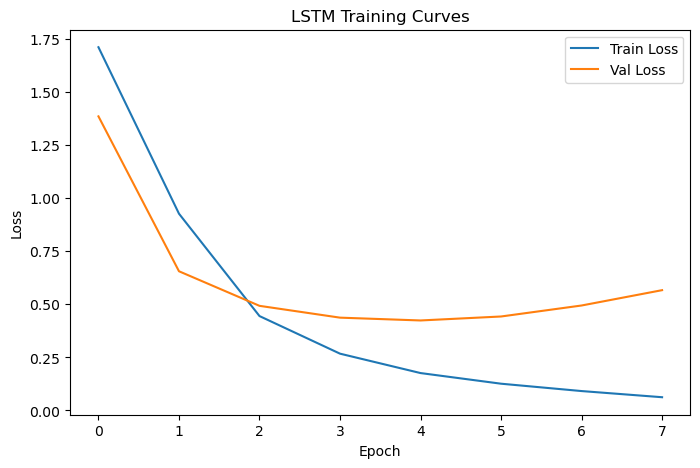

In [108]:
lstm_model = LSTMClassifier(
    vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_classes=6, pad_idx=pad_token_id, dropout=0.3)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)


lstm_model, lstm_train_loss, lstm_val_loss = train_model(
    lstm_model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3)

plt.figure(figsize=(8,5))
plt.plot(lstm_train_loss, label='Train Loss')
plt.plot(lstm_val_loss, label='Val Loss')
plt.legend()
plt.title('LSTM Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Epoch 1/20 - Train Loss: 1.6554 - Val Loss: 1.2778
Epoch 2/20 - Train Loss: 0.7945 - Val Loss: 0.5203
Epoch 3/20 - Train Loss: 0.3363 - Val Loss: 0.3626
Epoch 4/20 - Train Loss: 0.1955 - Val Loss: 0.3884
Epoch 5/20 - Train Loss: 0.1185 - Val Loss: 0.4087
Epoch 6/20 - Train Loss: 0.0792 - Val Loss: 0.4325
Early stopping at epoch 6


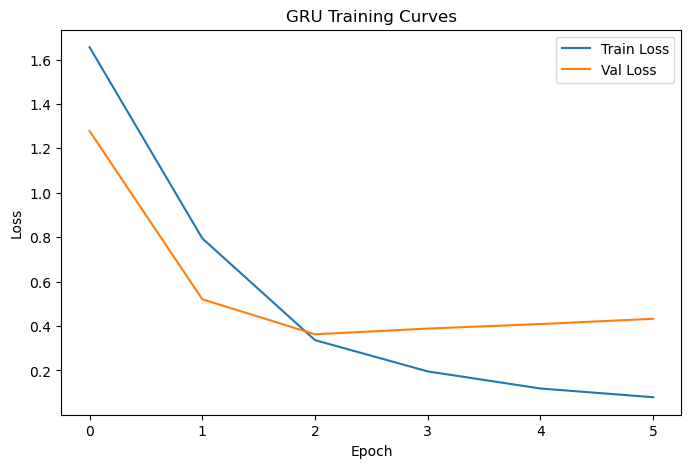

In [109]:
gru_model = GRUClassifier(
    vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_classes=6, pad_idx=pad_token_id, dropout=0.3
)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)

gru_model, gru_train_loss, gru_val_loss = train_model(
    gru_model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3)

plt.figure(figsize=(8,5))
plt.plot(gru_train_loss, label='Train Loss')
plt.plot(gru_val_loss, label='Val Loss')
plt.legend()
plt.title('GRU Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 - Train Loss: 0.7392 - Val Loss: 0.2206
Epoch 2/5 - Train Loss: 0.2118 - Val Loss: 0.1827
Epoch 3/5 - Train Loss: 0.1618 - Val Loss: 0.2277
Epoch 4/5 - Train Loss: 0.1210 - Val Loss: 0.2334
Early stopping at epoch 4


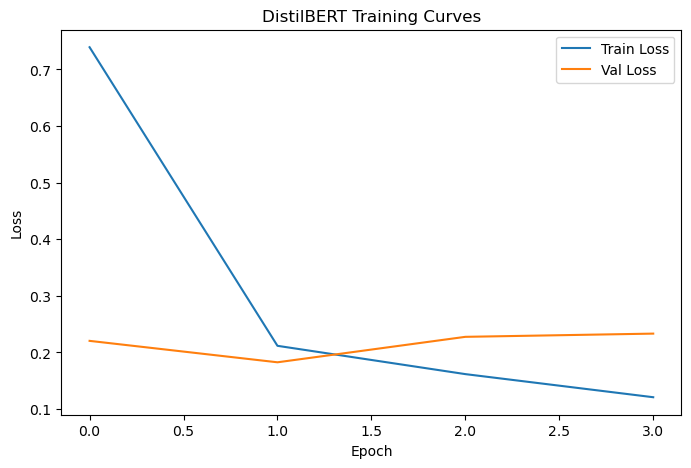

In [110]:
import copy

distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6).to(device)

optimizer = AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

def train_distilbert(model, train_loader, val_loader, criterion, optimizer, epochs=5, patience=2):
    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    best_model_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

distilbert_model, db_train_loss, db_val_loss = train_distilbert(distilbert_model, train_loader, val_loader, criterion, optimizer, epochs=5, patience=2)

plt.figure(figsize=(8,5))
plt.plot(db_train_loss, label='Train Loss')
plt.plot(db_val_loss, label='Val Loss')
plt.legend()
plt.title('DistilBERT Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

LSTM Test Accuracy: 0.8775
              precision    recall  f1-score   support

     sadness       0.95      0.91      0.93       581
         joy       0.92      0.87      0.90       695
        love       0.68      0.85      0.76       159
       anger       0.83      0.91      0.87       275
        fear       0.90      0.80      0.85       224
    surprise       0.62      0.89      0.73        66

    accuracy                           0.88      2000
   macro avg       0.82      0.87      0.84      2000
weighted avg       0.89      0.88      0.88      2000



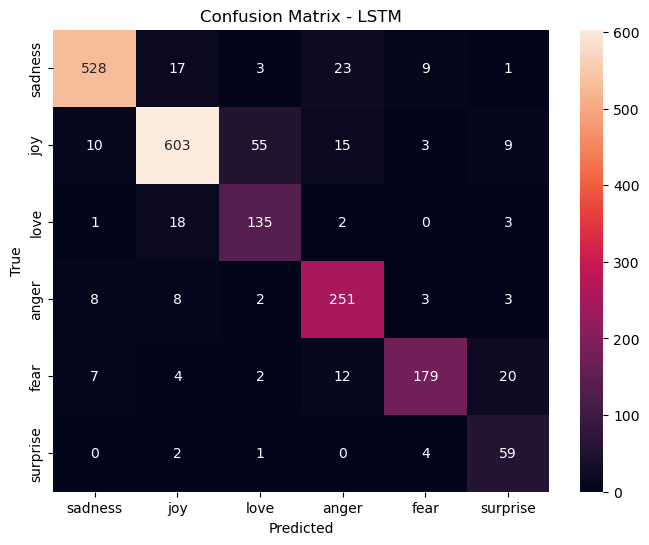

GRU Test Accuracy: 0.8465
              precision    recall  f1-score   support

     sadness       0.95      0.87      0.91       581
         joy       0.94      0.77      0.85       695
        love       0.63      0.93      0.75       159
       anger       0.76      0.94      0.84       275
        fear       0.85      0.82      0.83       224
    surprise       0.60      0.95      0.74        66

    accuracy                           0.85      2000
   macro avg       0.79      0.88      0.82      2000
weighted avg       0.87      0.85      0.85      2000



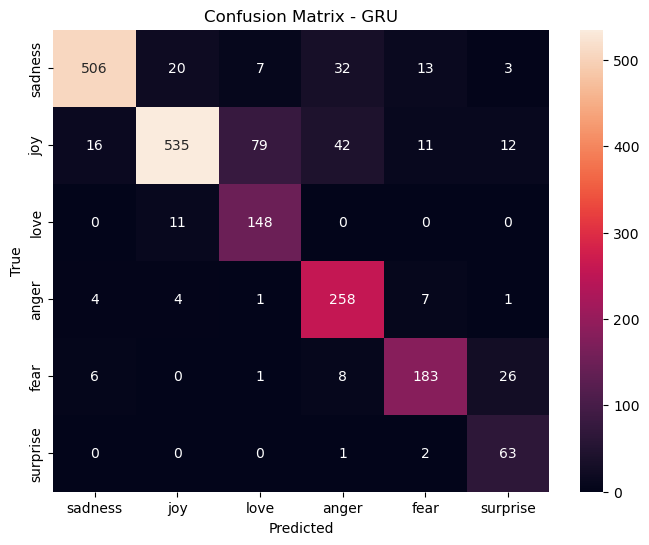

DistilBERT Test Accuracy: 0.9220
              precision    recall  f1-score   support

     sadness       0.99      0.93      0.96       581
         joy       0.99      0.90      0.94       695
        love       0.73      0.99      0.84       159
       anger       0.87      0.97      0.92       275
        fear       0.90      0.88      0.89       224
    surprise       0.71      0.83      0.77        66

    accuracy                           0.92      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.93      0.92      0.92      2000



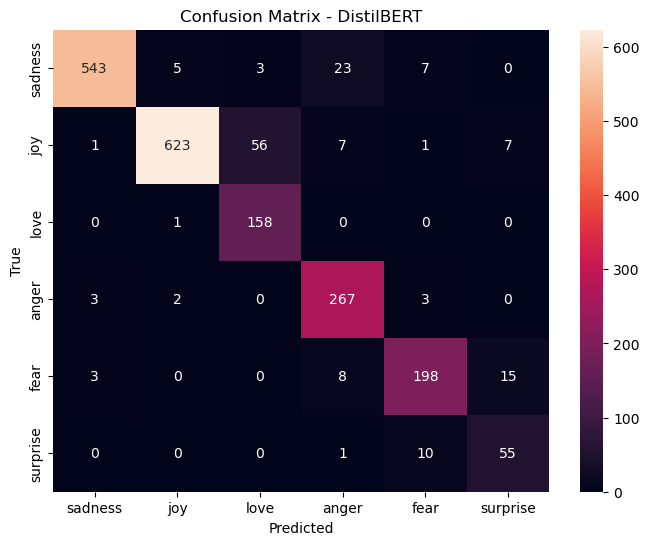

In [111]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            if model_name == 'DistilBERT':
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            else:
                logits = model(input_ids, attention_mask)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=label_names, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"{model_name} Test Accuracy: {acc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=label_names))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc, report, cm

lstm_acc, lstm_report, lstm_cm = evaluate_model(lstm_model, test_loader, 'LSTM')
gru_acc, gru_report, gru_cm = evaluate_model(gru_model, test_loader, 'GRU')
db_acc, db_report, db_cm = evaluate_model(distilbert_model, test_loader, 'DistilBERT')

     Model  Test Accuracy  Macro F1  Weighted F1
      LSTM         0.8775  0.838632     0.880152
       GRU         0.8465  0.818466     0.850304
DistilBERT         0.9220  0.887091     0.924169


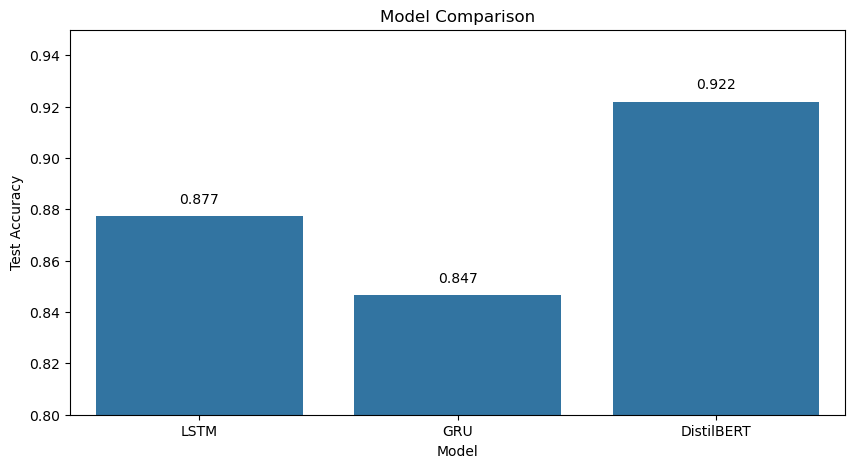

In [112]:
comparison_data = {
    'Model': ['LSTM', 'GRU', 'DistilBERT'],
    'Test Accuracy': [lstm_acc, gru_acc, db_acc],
    'Macro F1': [lstm_report['macro avg']['f1-score'], gru_report['macro avg']['f1-score'], db_report['macro avg']['f1-score']],
    'Weighted F1': [lstm_report['weighted avg']['f1-score'], gru_report['weighted avg']['f1-score'], db_report['weighted avg']['f1-score']]
}

comparison_df = pd.DataFrame(comparison_data)

print(comparison_df.to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Test Accuracy', data=comparison_df)
plt.title('Model Comparison')
plt.ylim(0.8, 0.95)

for i, v in enumerate(comparison_df['Test Accuracy']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.show()

In [113]:
def predict_emotion(text, model, model_type='DistilBERT'):
    model.eval()

    inputs = tokenizer(text, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        if model_type == 'DistilBERT':
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        else:
            logits = model(input_ids, attention_mask)

    pred = torch.argmax(logits, dim=1).item()

    return label_names[pred], torch.softmax(logits, dim=1).cpu().numpy()[0]

In [114]:
distilbert_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [115]:
errors = []

for i in range(len(test_texts)):
    if all_labels[i] != all_preds[i]:
        errors.append({
            "text": test_texts[i],
            "actual": label_names[all_labels[i]],
            "predicted": label_names[all_preds[i]]
        })

errors_df = pd.DataFrame(errors)
print("Total errors:", len(errors_df))
errors_df.head(10)

Total errors: 156


,text,actual,predicted
0,i explain why i clung to a relationship with a...,joy,love
1,i don t feel particularly agitated,fear,anger
2,i feel like my only role now would be to tear ...,sadness,anger
3,im not sure the feeling of loss will ever go a...,sadness,love
4,i spent wandering around still kinda dazed and...,joy,sadness
5,i feel like i am in paradise kissing those swe...,joy,love
6,i was feeling weird the other day and it went ...,fear,surprise
7,when a friend dropped a frog down my neck,anger,fear
8,i feel agitated with myself that i did not for...,fear,anger
9,i looked at mabel this morning i named my left...,fear,surprise


In [121]:
distilbert_model.save_pretrained("emotion_model")
tokenizer.save_pretrained("emotion_model")

import json

with open("emotion_model/label_names.json", "w") as f:
    json.dump(label_names, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]